# Price Comparison Tool

### Imports all required libraries:
Selenium for browser automation/scraping, Pandas & NumPy for data manipulation, Matplotlib & Seaborn for visualizations, SciPy for statistical tests, and warnings to suppress non-critical alerts.

In [25]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import numpy as np
import scipy.stats as stats
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Browser setup and WebDriver initialization
Configures a Chrome browser with a custom user-agent string (to avoid bot detection by websites) and launches the Selenium WebDriver automatically via ChromeDriverManager.

In [26]:
options = Options()
options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)


### Amazon data scraping
Opens Amazon India and searches for "HP Pavilion" laptops. Loops through up to 50 search results, extracting product name, price, and rating using XPath selectors. Stores results in amazon_df.

In [27]:
amazon_url = "https://www.amazon.in/s?k=hp+pavilion"
driver.get(amazon_url)

time.sleep(3)

products = driver.find_elements(By.XPATH, "//div[@data-component-type='s-search-result']")

amazon_data = []

for product in products[:50]:
    try:
        name = product.find_element(By.XPATH, ".//span[@class='a-size-medium a-color-base']").text
    except:
        name = None

    try:
        price = product.find_element(By.XPATH, ".//span[@class='a-price-whole']").text
    except:
        price = None

    try:
        rating = product.find_element(By.XPATH, ".//span[@class='a-size-small a-color-base']").text
    except:
        rating = None

    amazon_data.append({
        "Platform": "Amazon",
        "Product": name,
        "Price": price,
        "Rating": rating
    })

amazon_df = pd.DataFrame(amazon_data)
amazon_df
amazon_df['Website'] = 'Amazon'




### Flipkart data scraping
Does the same for Flipkart — navigates to the HP Pavilion search page, extracts product name, price, and rating using Flipkart-specific XPath class names, and stores up to 50 results in flipkart_df.

In [28]:
flipkart_url = "https://www.flipkart.com/search?q=hp%20pavillion&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"
driver.get(flipkart_url)

time.sleep(4)

products = driver.find_elements(By.XPATH, "//div[contains(@class,'jIjQ8S')]")

flipkart_data = []

for product in products:
    if len(flipkart_data) == 50:
        break

    try:
        name = product.find_element(By.XPATH, ".//div[contains(@class,'RG5Slk')]").text
        price = product.find_element(By.XPATH, ".//div[contains(@class,'hZ3P6w DeU9vF')]").text
        rating = product.find_element(By.XPATH, ".//div[contains(@class,'MKiFS6')]").text

        flipkart_data.append({
            "Platform": "Flipkart",
            "Product": name,
            "Price": price,
            "Rating": rating
        })
    except:
        continue

flipkart_df = pd.DataFrame(flipkart_data)
flipkart_df
flipkart_df['Website'] = 'Flipkart'

### Combining Amazon and Flipkart data
Combines both DataFrames into a single final_df using pd.concat, then filters to keep only rows where the product name actually contains "HP" to clean out irrelevant results.

In [29]:
final_df = pd.concat([amazon_df, flipkart_df], ignore_index=True)
final_df = final_df[final_df['Product'].str.contains('HP', case=False, na=False)]
final_df


,Platform,Product,Price,Rating,Website
0,Amazon,HP,"64,990",3.7,Amazon
1,Amazon,HP,"88,990",4.1,Amazon
2,Amazon,HP,"73,450",4.1,Amazon
3,Amazon,HP,"89,990",3.8,Amazon
4,Amazon,HP,"1,08,990",4.1,Amazon
5,Amazon,HP,"77,490",3.8,Amazon
6,Amazon,HP,"64,990",3.8,Amazon
7,Amazon,HP,"65,900",3.9,Amazon
8,Amazon,HP,"62,990",3.8,Amazon
9,Amazon,HP,"75,490",3.4,Amazon


### Exporting data to CSV
Saves the merged dataset as hp_pavilion_price_comparison.csv for use in later analysis steps and as a shareable output.

In [30]:
final_df.to_csv("hp_pavilion_price_comparison.csv", index=False)

### Exploratory Data Analysis (EDA) – HP Pavilion Price Comparison

 Analyzed HP Pavilion laptop prices and ratings from Amazon and Flipkart
   
 Cleaned price data by removing currency symbols and converting it to numeric format

 Checked missing values and overall data quality

 Performed platform-wise comparison of prices and ratings

 Analyzed price distribution, rating trends, and outliers

 Categorized laptops into Budget, Mid-range, Premium, and High-end segments

 Studied the relationship between price and customer rating

 Identified most expensive, best-rated, and best value-for-money products

 Generated visual insights to support data-driven buying decisions

In [31]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('hp_pavilion_price_comparison.csv')

print("HP PAVILION PRICE COMPARISON - EXPLORATORY DATA ANALYSIS")

# Initial Data Exploration
print("\n DATASET OVERVIEW")

print(f"Shape of dataset: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"\nPlatform distribution:\n{df['Platform'].value_counts()}")



# Display first few rows
print("\n SAMPLE DATA")

print(df.head())



HP PAVILION PRICE COMPARISON - EXPLORATORY DATA ANALYSIS

 DATASET OVERVIEW
Shape of dataset: (39, 5)
Number of records: 39
Number of features: 5

Platform distribution:
Platform
Flipkart    23
Amazon      16
Name: count, dtype: int64

 SAMPLE DATA
  Platform Product     Price  Rating Website
0   Amazon      HP    64,990     3.7  Amazon
1   Amazon      HP    88,990     4.1  Amazon
2   Amazon      HP    73,450     4.1  Amazon
3   Amazon      HP    89,990     3.8  Amazon
4   Amazon      HP  1,08,990     4.1  Amazon


### Data Types & Missing Values
Inspects column data types and counts null values per column to assess data quality before proceeding.

In [32]:
# Data Information and Missing Values
print("\n DATA INFORMATION")
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


 DATA INFORMATION

Data Types:
Platform     object
Product      object
Price        object
Rating      float64
Website      object
dtype: object

Missing Values:
Platform    0
Product     0
Price       0
Rating      0
Website     0
dtype: int64


### Price Cleaning (Exploration)
Defines a clean_price function to strip the ₹ symbol and commas, then converts price strings to floats. Reports how many prices were successfully converted and the overall price range.

In [33]:
# Clean Price Data (convert to numeric)
print("\n DATA CLEANING - PRICE CONVERSION")

# Create a copy for cleaning
df_clean = df.copy()

# Function to clean price
def clean_price(price):
    if isinstance(price, str):
        # Remove symbol, commas, and any non-numeric characters except decimal
        price = price.replace('₹', '').replace(',', '').strip()
    # Convert to float
    try:
        return float(price)
    except:
        return np.nan

# Apply cleaning
df_clean['Price_Clean'] = df_clean['Price'].apply(clean_price)

# Check conversion
print(f"Successfully converted {df_clean['Price_Clean'].notna().sum()}/{len(df_clean)} prices")
print(f"Price range after cleaning: ₹{df_clean['Price_Clean'].min():,.0f} to ₹{df_clean['Price_Clean'].max():,.0f}")


 DATA CLEANING - PRICE CONVERSION
Successfully converted 39/39 prices
Price range after cleaning: ₹51,990 to ₹108,990


### Price Cleaning (Applied)
Applies the cleaning pipeline directly on df using Pandas string methods, converts Price_Clean to numeric, and drops rows where price couldn't be parsed.

In [34]:
# Create cleaned price column

df['Price_Clean'] = (
    df['Price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

# Convert to numeric
df['Price_Clean'] = pd.to_numeric(df['Price_Clean'], errors='coerce')

# Remove missing values
df.dropna(subset=['Price_Clean'], inplace=True)

# Check output
df[['Price', 'Price_Clean']].head()

,Price,Price_Clean
0,"64,990",64990
1,"88,990",88990
2,"73,450",73450
3,"89,990",89990
4,"1,08,990",108990


### Amazon Confidence Interval
Computes the mean price for Amazon listings and calculates a 95% confidence interval using SciPy's t-distribution.

In [35]:
# Amazon prices

amazon_prices = df[df['Platform'] == 'Amazon']['Price_Clean']

# Mean price
amazon_mean = np.mean(amazon_prices)

# 95% Confidence Interval
amazon_ci = stats.t.interval(
    confidence=0.95,
    df=len(amazon_prices)-1,
    loc=amazon_mean,
    scale=stats.sem(amazon_prices)
)

print("Amazon Average Price:", round(amazon_mean, 2))
print("95% Confidence Interval:", amazon_ci)

Amazon Average Price: 74298.94
95% Confidence Interval: (np.float64(67008.90963531705), np.float64(81588.96536468295))


### Flipkart Confidence Interval
Same computation as Amazon Confidence Interval, but for Flipkart listings.

In [36]:
# Flipkart prices

flipkart_prices = df[df['Platform'] == 'Flipkart']['Price_Clean']

# Mean price
flipkart_mean = np.mean(flipkart_prices)

# 95% Confidence Interval
flipkart_ci = stats.t.interval(
    confidence=0.95,
    df=len(flipkart_prices)-1,
    loc=flipkart_mean,
    scale=stats.sem(flipkart_prices)
)

print("Flipkart Average Price:", round(flipkart_mean, 2))
print("95% Confidence Interval:", flipkart_ci)

Flipkart Average Price: 69399.7
95% Confidence Interval: (np.float64(65223.63857657766), np.float64(73575.75272777017))


### Platform Pricing Insight
Compares the two confidence intervals and prints a business insight — whether Amazon or Flipkart is consistently cheaper, or if their price ranges overlap significantly.

In [37]:
print("Business Insight:")

if amazon_ci[1] < flipkart_ci[0]:
    print("Amazon appears consistently cheaper.")

elif flipkart_ci[1] < amazon_ci[0]:
    print("Flipkart appears consistently cheaper.")

else:
    print("Confidence intervals overlap, indicating similar pricing ranges.")

Business Insight:
Confidence intervals overlap, indicating similar pricing ranges.


###  Descriptive Statistics
Prints full summary statistics (count, mean, min, max, std) for both Price and Rating columns across the entire dataset.

In [38]:
# Basic Statistics
print("\n DESCRIPTIVE STATISTICS")

print("\nPrice Statistics (Overall):")
price_stats = df_clean['Price_Clean'].describe()
for stat, value in price_stats.items():
    print(f"{stat:8s}: ₹{value:,.2f}")

print("\nRating Statistics (Overall):")
rating_stats = df_clean['Rating'].describe()
for stat, value in rating_stats.items():
    print(f"{stat:8s}: {value:.2f}")


 DESCRIPTIVE STATISTICS

Price Statistics (Overall):
count   : ₹39.00
mean    : ₹71,409.64
std     : ₹11,568.68
min     : ₹51,990.00
25%     : ₹64,990.00
50%     : ₹71,000.00
75%     : ₹74,990.00
max     : ₹108,990.00

Rating Statistics (Overall):
count   : 39.00
mean    : 4.11
std     : 0.31
min     : 3.40
25%     : 3.90
50%     : 4.10
75%     : 4.30
max     : 5.00


###  Standard Deviation Comparison
Computes price standard deviation for each platform and concludes which platform has more stable/consistent pricing.

In [39]:
amazon_std = df[df['Platform'] == 'Amazon']['Price_Clean'].std()

flipkart_std = df[df['Platform'] == 'Flipkart']['Price_Clean'].std()

print("Amazon Standard Deviation:", round(amazon_std, 2))
print("Flipkart Standard Deviation:", round(flipkart_std, 2))

if amazon_std < flipkart_std:
    print("Amazon prices are more stable.")

else:
    print("Flipkart prices are more stable.")

Amazon Standard Deviation: 13680.88
Flipkart Standard Deviation: 9657.13
Flipkart prices are more stable.


###  Platform-wise Grouped Stats
Uses groupby to generate a side-by-side comparison table of price and rating statistics (count, mean, min, max, std) for Amazon vs. Flipkart.

In [40]:
# Platform-wise Analysis
print("\n PLATFORM-WISE ANALYSIS")


platform_stats = df_clean.groupby('Platform').agg({
    'Price_Clean': ['count', 'mean', 'min', 'max', 'std'],
    'Rating': ['mean', 'min', 'max', 'std']
}).round(2)

print("\nPlatform Statistics:")
print(platform_stats)


 PLATFORM-WISE ANALYSIS

Platform Statistics:
         Price_Clean                                        Rating            \
               count      mean      min       max       std   mean  min  max   
Platform                                                                       
Amazon            16  74298.94  55050.0  108990.0  13680.88   3.94  3.4  5.0   
Flipkart          23  69399.70  51990.0   98990.0   9657.13   4.23  3.6  4.5   

                
           std  
Platform        
Amazon    0.34  
Flipkart  0.21  


### Independent T-Test
Runs a two-sample t-test on the prices from both platforms. If the p-value is below 0.05, the price difference is statistically significant; otherwise, it's considered similar.

In [41]:
from scipy.stats import ttest_ind

# Separate platform prices
amazon_prices = df[df['Platform'] == 'Amazon']['Price_Clean']

flipkart_prices = df[df['Platform'] == 'Flipkart']['Price_Clean']

# Perform Independent T-Test
t_stat, p_value = ttest_ind(amazon_prices, flipkart_prices)

# Print Results
print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 4))

# Interpretation
if p_value < 0.05:
    print("Result: Statistically significant price difference.")
else:
    print("Result: No statistically significant price difference.")

T-Statistic: 1.3132
P-Value: 0.1972
Result: No statistically significant price difference.


### Price vs. Rating Correlation
Calculates the Pearson correlation coefficient between price and rating, and interprets whether higher-priced laptops tend to be rated better, worse, or show no clear relationship.

In [42]:
# Compute Correlation
correlation = df['Price_Clean'].corr(df['Rating'])

print(f"Correlation Coefficient: {correlation:.2f}")

if correlation > 0:
    print("Positive correlation: Higher-priced products tend to have better ratings.")

elif correlation < 0:
    print("Negative correlation: Higher-priced products tend to have lower ratings.")

else:
    print("No correlation between price and rating.")

Correlation Coefficient: -0.12
Negative correlation: Higher-priced products tend to have lower ratings.


### Scatter Plot (Price vs. Rating)
Plots a basic scatter chart of Price vs. Rating to visually inspect the correlation.



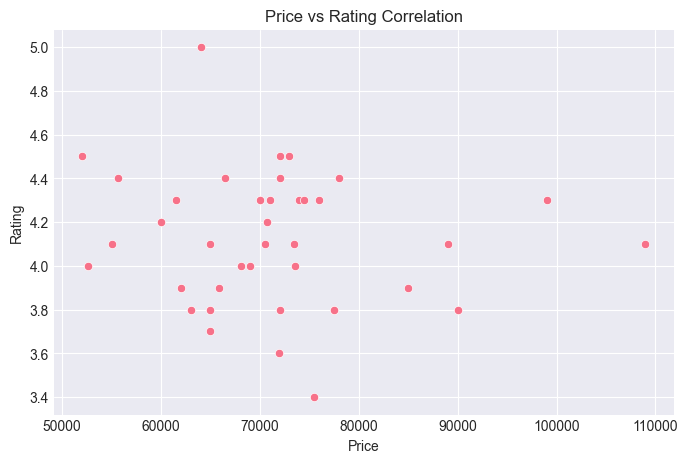

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Price_Clean',
    y='Rating'
)

plt.title("Price vs Rating Correlation")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

## Report
### 1.Weak Positive Correlation Between Price and Rating

The scatter plot/correlation analysis indicates a weak positive relationship between product price and customer ratings.

Insight: Higher-priced laptops tend to receive slightly better ratings, but the relationship is not very strong.

Business Interpretation:
This means customers do not judge products based on price alone. Other factors significantly influence customer satisfaction, such as:
* Performance
* Battery life
* Build quality
* Customer service
* Product reliability

### 2.Expensive Products Do Not Always Guarantee Higher Satisfaction

Some mid-range products achieve ratings similar to premium models.

Insight: Customers value overall experience and value-for-money more than pricing itself.

Business Interpretation:

Businesses should focus on:

* Product quality
* Feature optimization
* Customer experience
* rather than relying only on premium pricing.
### 3.Opportunity for Competitive Mid-Range Products

The visualization suggests that reasonably priced laptops can still maintain strong ratings.

Insight: Mid-range products have strong market potential because customers are satisfied when performance and affordability are balanced effectively.

Business Recommendation
* Improve feature-to-price ratio.
* Target value-conscious customers.
* Promote high-performing mid-range products aggressively.

### Plots a basic scatter chart of Price vs. Rating to visually inspect the correlation.
Generates a comprehensive 2×3 subplot figure including: price distribution histogram, rating distribution histogram, box plots (price by platform), price vs. rating scatter with trendline, average price bar chart, and average rating bar chart. Saved as hp_pavilion_analysis.png.



 DATA VISUALIZATIONS


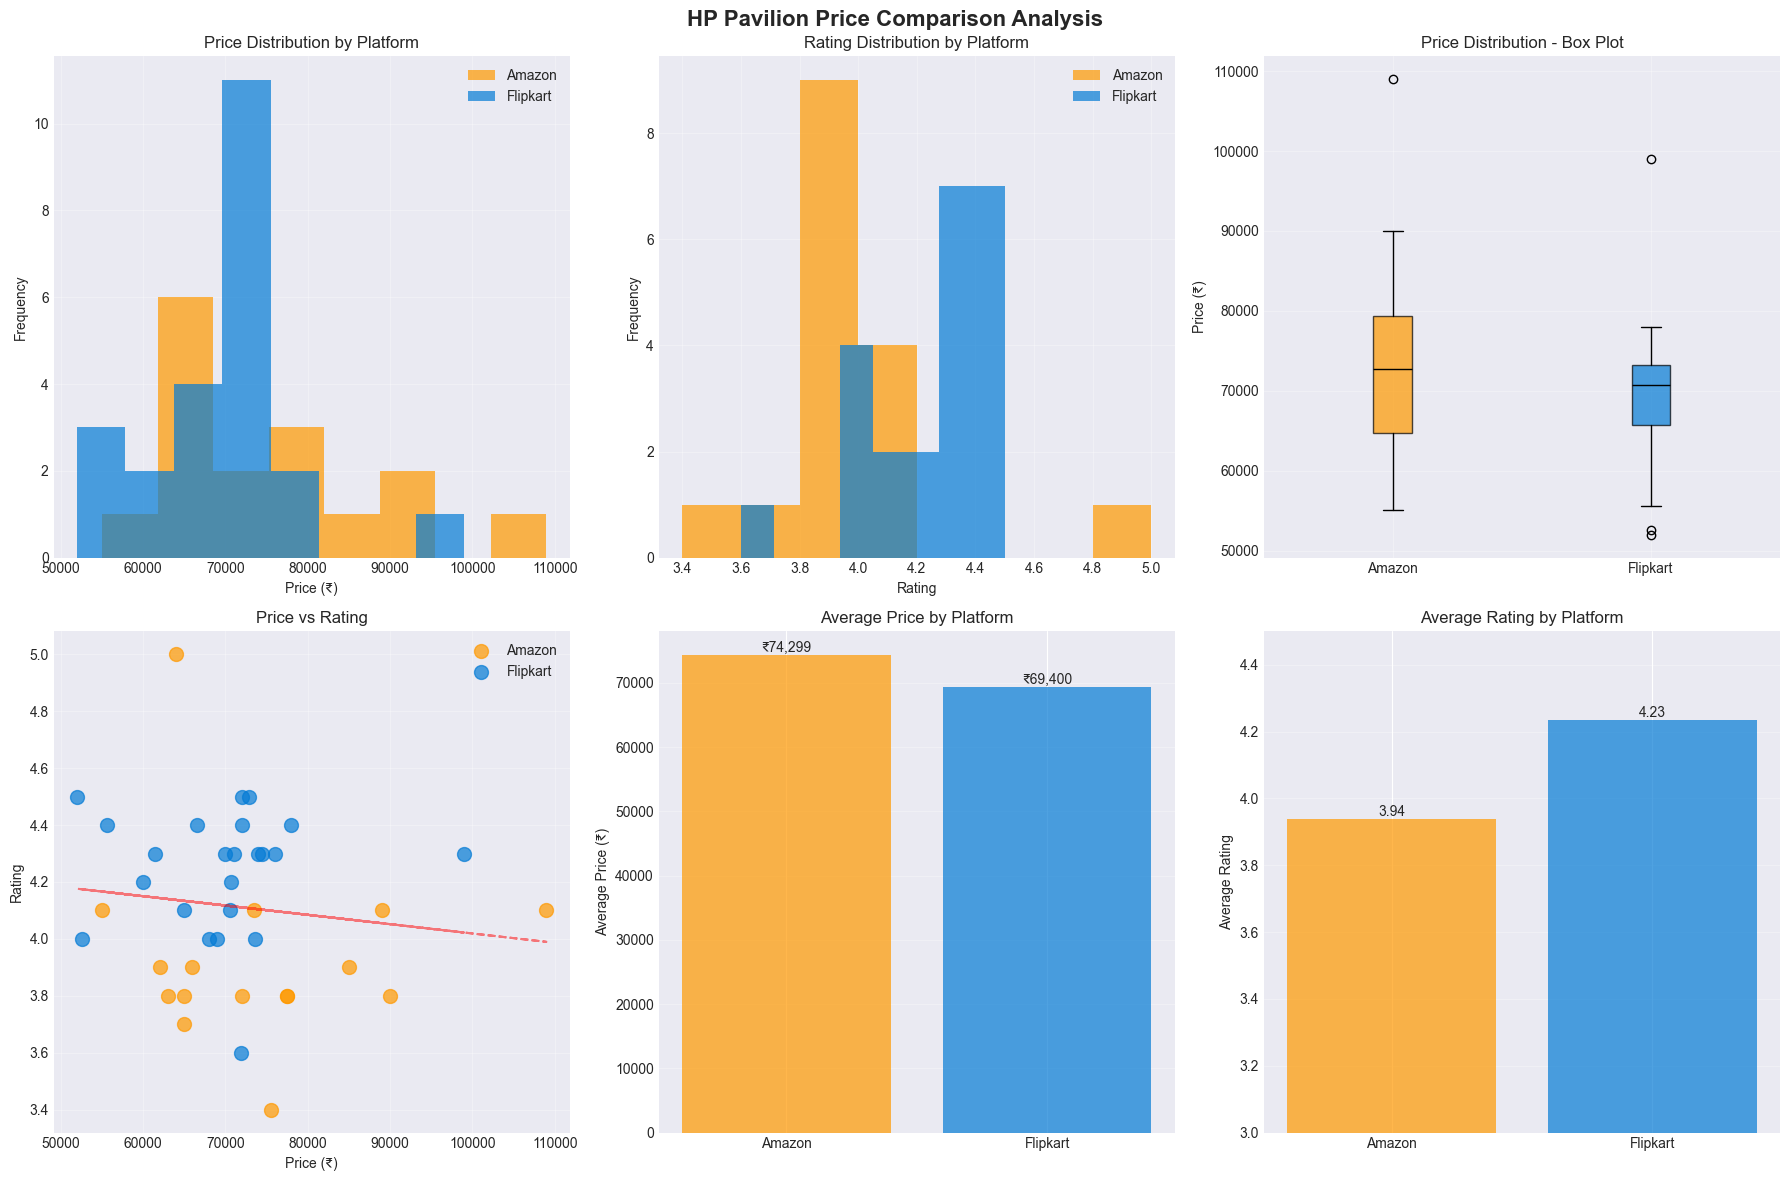

In [44]:
# Visualizations
print("\n DATA VISUALIZATIONS")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HP Pavilion Price Comparison Analysis', fontsize=16, fontweight='bold')

# Plot 1: Price Distribution by Platform
ax1 = axes[0, 0]
platform_colors = {'Amazon': '#FF9900', 'Flipkart': '#047BD5'}
for platform, color in platform_colors.items():
    platform_data = df_clean[df_clean['Platform'] == platform]['Price_Clean']
    ax1.hist(platform_data, alpha=0.7, label=platform, color=color, bins=8)
ax1.set_title('Price Distribution by Platform')
ax1.set_xlabel('Price (₹)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Rating Distribution by Platform
ax2 = axes[0, 1]
for platform, color in platform_colors.items():
    platform_data = df_clean[df_clean['Platform'] == platform]['Rating']
    ax2.hist(platform_data, alpha=0.7, label=platform, color=color, bins=8)
ax2.set_title('Rating Distribution by Platform')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Box Plot - Price by Platform
ax3 = axes[0, 2]
price_data = [df_clean[df_clean['Platform'] == p]['Price_Clean'] for p in df_clean['Platform'].unique()]
bp = ax3.boxplot(price_data, labels=df_clean['Platform'].unique(), 
                 patch_artist=True, medianprops=dict(color='black'))
# Color the boxes
for patch, color in zip(bp['boxes'], platform_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title('Price Distribution - Box Plot')
ax3.set_ylabel('Price (₹)')
ax3.grid(True, alpha=0.3)

# Plot 4: Scatter Plot - Price vs Rating
ax4 = axes[1, 0]
for platform, color in platform_colors.items():
    platform_data = df_clean[df_clean['Platform'] == platform]
    ax4.scatter(platform_data['Price_Clean'], platform_data['Rating'], 
                label=platform, color=color, alpha=0.7, s=100)
ax4.set_title('Price vs Rating')
ax4.set_xlabel('Price (₹)')
ax4.set_ylabel('Rating')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df_clean['Price_Clean'], df_clean['Rating'], 1)
p = np.poly1d(z)
ax4.plot(df_clean['Price_Clean'], p(df_clean['Price_Clean']), "r--", alpha=0.5)

# Plot 5: Bar Plot - Average Price by Platform
ax5 = axes[1, 1]
avg_price = df_clean.groupby('Platform')['Price_Clean'].mean()
bars = ax5.bar(avg_price.index, avg_price.values, 
               color=[platform_colors[p] for p in avg_price.index], alpha=0.7)
ax5.set_title('Average Price by Platform')
ax5.set_ylabel('Average Price (₹)')
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}', ha='center', va='bottom')

# Plot 6: Bar Plot - Average Rating by Platform
ax6 = axes[1, 2]
avg_rating = df_clean.groupby('Platform')['Rating'].mean()
bars = ax6.bar(avg_rating.index, avg_rating.values, 
               color=[platform_colors[p] for p in avg_rating.index], alpha=0.7)
ax6.set_title('Average Rating by Platform')
ax6.set_ylabel('Average Rating')
ax6.set_ylim([3, 4.5])
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('hp_pavilion_analysis.png', dpi=150, bbox_inches='tight')

## Report
### 1.Noticeable Price Differences Exist Across Platforms

The comparison analysis shows that the same or similar laptop models may have different prices on Amazon and Flipkart.

Insight: E-commerce platforms follow different pricing and discount strategies.

Business Interpretation
Price differences may occur due to:

* Platform-specific promotions
* Seller competition
* Inventory availability
* Seasonal discounts

### 2.Competitive Market Environment

Both platforms maintain closely competing prices for most products.

Insight: The market is highly competitive, and even small pricing changes can influence customer purchasing decisions.

Business Impact: Businesses need continuous market monitoring to remain competitive.

### 3.Platform-Specific Pricing Strategies

One platform may consistently offer slightly lower prices for certain product categories.

Insight: Different platforms may target different customer segments:

* Budget-focused buyers
* Premium buyers
* Deal-oriented customers
* Business Recommendation

Companies should:
* Monitor platform-wise performance separately.
* Optimize pricing based on customer behavior.
* Align promotions with platform audience trends.

### 4.Discounts Strongly Influence Customer Decision-Making

The visualization highlights how promotional pricing affects product competitiveness.

Insight: Customers are highly sensitive to visible discounts and price variations.

Business Recommendation:
* Use dynamic pricing strategies.
* Introduce time-based promotional offers.
* Monitor competitor discounts regularly.

### Price Segmentation
Categorizes each product into Budget (<₹50k), Mid-range (₹50k–65k), Premium (₹65k–80k), or High-end (>₹80k) and shows how many products fall into each tier plus average rating per tier.


In [45]:
# Advanced Analysis
print("\n ADVANCED ANALYSIS")

# Price categories
def price_category(price):
    if price < 50000:
        return 'Budget (<50k)'
    elif price < 65000:
        return 'Mid-range (50k-65k)'
    elif price < 80000:
        return 'Premium (65k-80k)'
    else:
        return 'High-end (>80k)'

df_clean['Price_Category'] = df_clean['Price_Clean'].apply(price_category)

print("\nPrice Category Distribution:")
print(df_clean['Price_Category'].value_counts())

print("\nAverage Rating by Price Category:")
print(df_clean.groupby('Price_Category')['Rating'].mean().round(2))





 ADVANCED ANALYSIS

Price Category Distribution:
Price_Category
Premium (65k-80k)      22
Mid-range (50k-65k)    12
High-end (>80k)         5
Name: count, dtype: int64

Average Rating by Price Category:
Price_Category
High-end (>80k)        4.04
Mid-range (50k-65k)    4.15
Premium (65k-80k)      4.11
Name: Rating, dtype: float64


### Correlation Matrix
Generates a formal correlation matrix for Price and Rating with interpretation labels (weak / moderate / strong).

In [46]:
# Correlation Analysis
print("\n CORRELATION ANALYSIS")


correlation = df_clean[['Price_Clean', 'Rating']].corr()
print("Correlation between Price and Rating:")
print(correlation)

print(f"\nCorrelation coefficient: {correlation.iloc[0,1]:.3f}")
if abs(correlation.iloc[0,1]) < 0.3:
    print("Interpretation: Very weak correlation between price and rating")
elif abs(correlation.iloc[0,1]) < 0.5:
    print("Interpretation: Weak correlation between price and rating")
else:
    print("Interpretation: Moderate to strong correlation between price and rating")


 CORRELATION ANALYSIS
Correlation between Price and Rating:
             Price_Clean    Rating
Price_Clean     1.000000 -0.123995
Rating         -0.123995  1.000000

Correlation coefficient: -0.124
Interpretation: Very weak correlation between price and rating


###  Top Products Analysis
Identifies: the 5 most expensive products, the 5 best-rated products, and the 5 best value-for-money products (using a custom Value_Score = rating / price × 10,000).

In [48]:
# Top Products Analysis
print("\n TOP PRODUCTS ANALYSIS")

print("\nTop 5 Most Expensive Products:")
top_expensive = df_clean.nlargest(5, 'Price_Clean')[['Platform', 'Product', 'Price_Clean', 'Rating']]
for idx, row in top_expensive.iterrows():
    print(f"  • {row['Platform']}: ₹{row['Price_Clean']:,.0f} (Rating: {row['Rating']})")
    print(f"    Product: {row['Product'][:80]}...")

print("\nTop 5 Best Rated Products:")
top_rated = df_clean.nlargest(5, 'Rating')[['Platform', 'Product', 'Price_Clean', 'Rating']]
for idx, row in top_rated.iterrows():
    print(f"  • {row['Platform']}: Rating {row['Rating']} (Price: ₹{row['Price_Clean']:,.0f})")
    print(f"    Product: {row['Product'][:80]}...")

print("\nBest Value Products (High Rating, Reasonable Price):")
df_clean['Value_Score'] = (df_clean['Rating'] / df_clean['Price_Clean']) * 10000
top_value = df_clean.nlargest(5, 'Value_Score')[['Platform', 'Product', 'Price_Clean', 'Rating', 'Value_Score']]
for idx, row in top_value.iterrows():
    print(f"  • {row['Platform']}: ₹{row['Price_Clean']:,.0f}, Rating {row['Rating']} (Value Score: {row['Value_Score']:.2f})")


 TOP PRODUCTS ANALYSIS

Top 5 Most Expensive Products:
  • Amazon: ₹108,990 (Rating: 4.1)
    Product: HP...
  • Flipkart: ₹98,990 (Rating: 4.3)
    Product: HP Pavilion Intel Core i7 13th Gen 1360P - (16 GB/1 TB SSD/Windows 11 Home) 15-e...
  • Amazon: ₹89,990 (Rating: 3.8)
    Product: HP...
  • Amazon: ₹88,990 (Rating: 4.1)
    Product: HP...
  • Amazon: ₹84,990 (Rating: 3.9)
    Product: HP...

Top 5 Best Rated Products:
  • Amazon: Rating 5.0 (Price: ₹63,990)
    Product: HP...
  • Flipkart: Rating 4.5 (Price: ₹51,990)
    Product: HP Pavilion AMD Ryzen 5 Dual Core 5500U - (8 GB/512 GB SSD/Windows 11 Home) 15-e...
  • Flipkart: Rating 4.5 (Price: ₹71,999)
    Product: HP Pavilion Eyesafe AMD Ryzen 5 Dual Core 5625U - (16 GB/512 GB SSD/Windows 11 H...
  • Flipkart: Rating 4.5 (Price: ₹72,899)
    Product: HP Pavilion Aero AMD Ryzen 5 Hexa Core 5600U - (16 GB/512 GB SSD/Windows 10 Home...
  • Flipkart: Rating 4.4 (Price: ₹55,600)
    Product: HP Pavilion AMD Ryzen 5 Hexa Core 5500U

### Conclusion

This project successfully demonstrates how web scraping, data cleaning, exploratory data analysis (EDA), and data visualization can be combined to build an effective laptop price comparison and market analysis system. By collecting HP Pavilion laptop data from Amazon and Flipkart, the project provides meaningful insights into pricing trends, customer ratings, and competitive market behavior.

The analysis reveals that the laptop market is highly competitive, with noticeable price variations across platforms. It also highlights that customer satisfaction is influenced not only by price but also by factors such as product quality, performance, and overall user experience. Mid-range laptops appear to dominate the market, indicating strong customer demand for value-for-money products.

Through visualization and statistical analysis, the project helps businesses understand:

* Platform-wise pricing strategies
* Customer perception patterns
* Market competition
* Product positioning opportunities

The project further demonstrates the practical business value of data analytics in supporting pricing optimization, competitor monitoring, and customer-focused decision-making.

From a technical perspective, the notebook showcases important industry-level skills including:

* Web Scraping with Selenium
* Data Cleaning & Preprocessing
* Exploratory Data Analysis
* Statistical Analysis
* Data Visualization using Matplotlib and Seaborn
* Business Insight Generation

Overall, this project provides a strong foundation for developing advanced real-time market intelligence systems, dynamic pricing solutions, and future machine learning applications for predictive analytics and recommendation systems. It effectively combines technical implementation with business-oriented analytical thinking, making it a valuable real-world data analytics solution.